In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
%matplotlib inline

In [ ]:
data = pd.read_csv("athlete_events.csv")

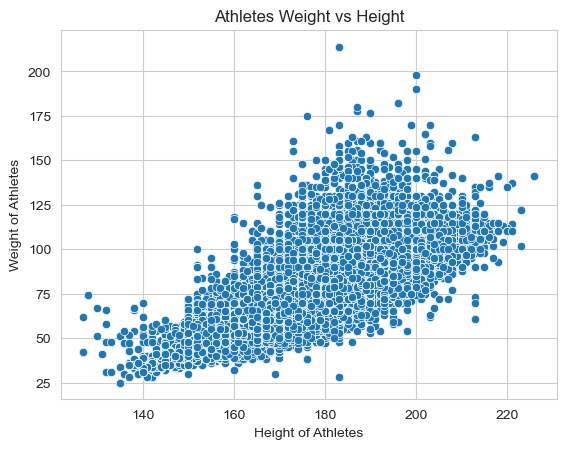

In [16]:
sns.set_style("whitegrid")
sns.scatterplot(x="Height", y="Weight", data= data)
plt.xlabel("Height of Athletes")
plt.ylabel("Weight of Athletes")
plt.title("Athletes Weight vs Height")
plt.show()

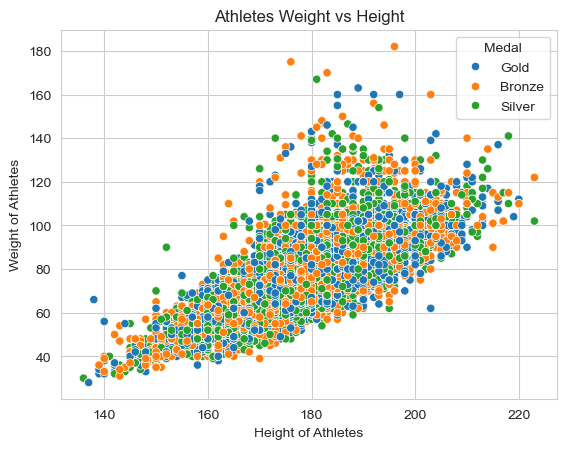

In [17]:
sns.set_style("whitegrid")
sns.scatterplot(x="Height", y="Weight",hue="Medal", data= data)
plt.xlabel("Height of Athletes")
plt.ylabel("Weight of Athletes")
plt.title("Athletes Weight vs Height")
plt.show()

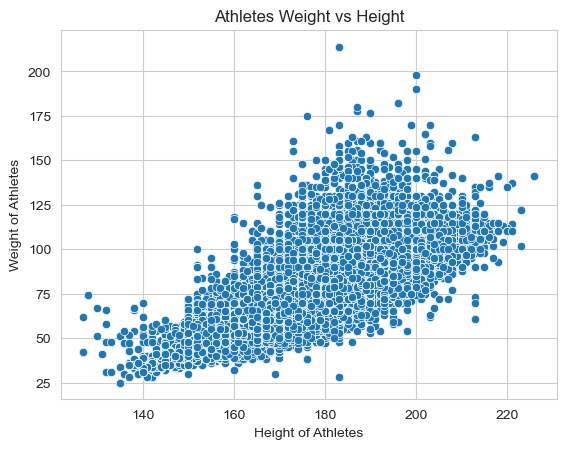

In [18]:
sns.set_style("whitegrid")
sns.scatterplot(x="Height", y="Weight", data= data)
plt.xlabel("Height of Athletes")
plt.ylabel("Weight of Athletes")
plt.title("Athletes Weight vs Height")
plt.show()

In [19]:
data

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [20]:
data["Medal"].unique()

array([nan, 'Gold', 'Bronze', 'Silver'], dtype=object)

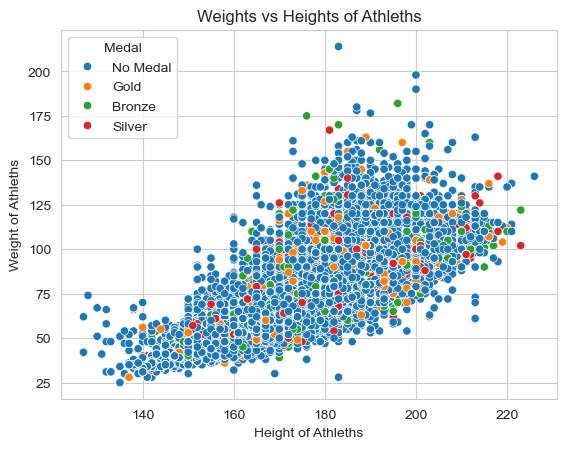

In [21]:
sns.set_style("whitegrid")
sns.scatterplot(x="Height",y="Weight", hue="Medal", data=data.assign(Medal=data["Medal"].fillna("No Medal")))
plt.xlabel("Height of Athleths")
plt.ylabel("Weight of Athleths")
plt.title("Weights vs Heights of Athleths")
plt.show()

In [32]:
import bisect

In [33]:
data["Height"].max()

226.0

In [34]:
data["Weight"].max()

214.0

In [35]:
heightBins = [0,100,110,120,130,140,150,160,170,180,190,200,210,220,230]

In [41]:
weightBins = [20,40,60,80,100,120,140,160,180,200,220]

In [48]:
data["Medal Status"] = np.where(data["Medal"].isna(),0,1)

In [53]:
data["Medal Status"].value_counts()

Medal Status
0    231333
1     39783
Name: count, dtype: int64

In [49]:
def heightlabs(height,bins):
    index = bisect.bisect_right(bins, height)
    lower_bounder = bins[index - 1]
    upper_bounder = bins[index]
    
    return f"{lower_bounder}-{upper_bounder}"

In [50]:
def Weightlabs(weight,bins):
    index = bisect.bisect_right(bins, weight)
    lower_bounder = bins[index - 1]
    upper_bounder = bins[index]
    
    return f"{lower_bounder}-{upper_bounder}"

In [51]:
table = (
    data.assign(
        Temporary_Height=pd.cut(data["Height"], bins=heightBins, include_lowest=True),
        Temporary_Weight=pd.cut(data["Weight"], bins=weightBins, include_lowest=True)
    )
    .pivot_table(
        values="Medal Status",
        index="Temporary_Weight",
        columns="Temporary_Height",
        aggfunc="mean",observed=False
    )
)

table

Temporary_Height,"(120.0, 130.0]","(130.0, 140.0]","(140.0, 150.0]","(150.0, 160.0]","(160.0, 170.0]","(170.0, 180.0]","(180.0, 190.0]","(190.0, 200.0]","(200.0, 210.0]","(210.0, 220.0]","(220.0, 230.0]"
Temporary_Weight,,,,,,,,,,,
"(19.999, 40.0]",NaN,0.098160,0.099448,0.078616,0.380952,0.000000,0.000000,NaN,NaN,NaN,NaN
"(40.0, 60.0]",0.0,0.031250,0.130123,0.105688,0.113720,0.131362,0.114894,0.000000,NaN,NaN,NaN
"(60.0, 80.0]",0.0,0.142857,0.285714,0.116186,0.123872,0.139438,0.154293,0.163671,0.166667,0.000000,NaN
"(80.0, 100.0]",NaN,NaN,NaN,0.037037,0.134615,0.158167,0.190104,0.238583,0.275442,0.344828,NaN
"(100.0, 120.0]",NaN,NaN,NaN,0.000000,0.186441,0.150538,0.182911,0.239377,0.358400,0.314286,0.333333
"(120.0, 140.0]",NaN,NaN,NaN,NaN,0.222222,0.188679,0.149584,0.195846,0.185714,0.333333,0.600000
"(140.0, 160.0]",NaN,NaN,NaN,NaN,NaN,0.250000,0.260274,0.147059,0.250000,1.000000,0.000000
"(160.0, 180.0]",NaN,NaN,NaN,NaN,NaN,0.333333,0.312500,0.000000,0.000000,0.000000,NaN
"(180.0, 200.0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.250000,NaN,NaN,NaN


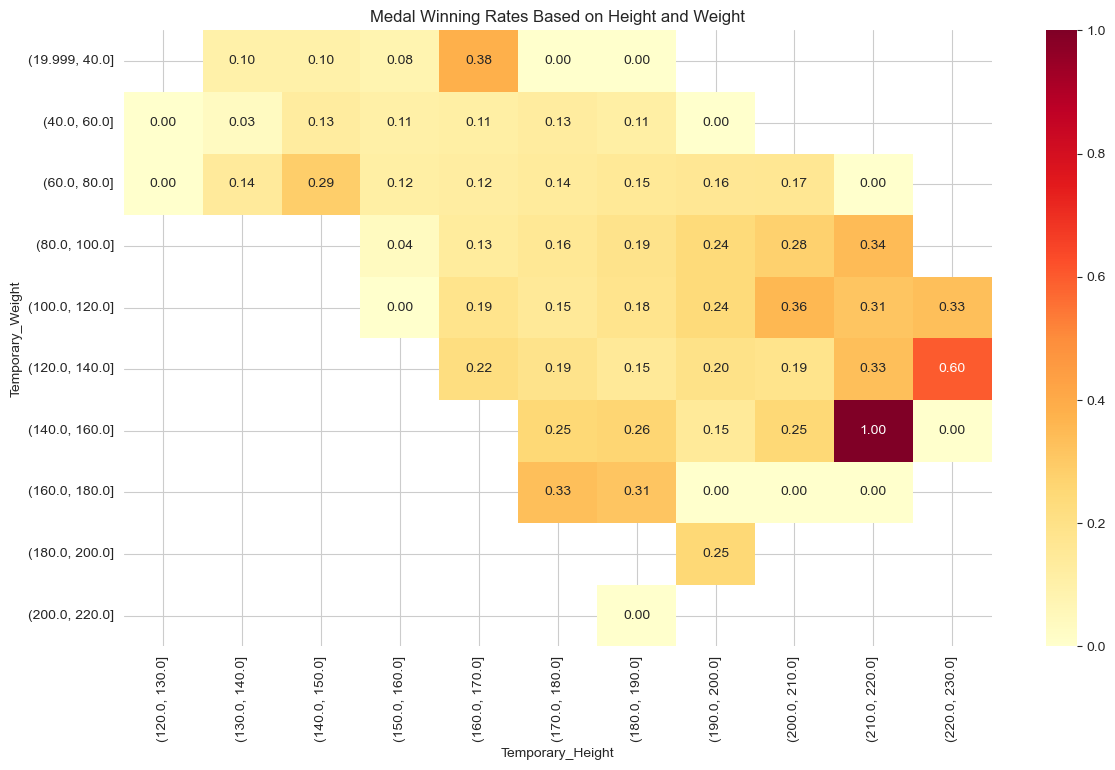

In [55]:
plt.figure(figsize=(14, 8)) 
sns.heatmap(table, annot=True, fmt=".2f", cmap="YlOrRd") 

plt.title("Medal Winning Rates Based on Height and Weight")
plt.show()

In [60]:
big_guy = data[(data["Height"] > 210) &(data["Height"] < 220) &(data["Weight"] > 140) & (data["Weight"] <= 160)]
display(big_guy)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal Status
127690,64369,Jnis Krmi,M,26.0,218.0,141.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Basketball,Basketball Men's Basketball,Silver,1
127691,64369,Jnis Krmi,M,30.0,218.0,141.0,Soviet Union,URS,1960 Summer,1960,Summer,Roma,Basketball,Basketball Men's Basketball,Silver,1
127692,64369,Jnis Krmi,M,34.0,218.0,141.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Basketball,Basketball Men's Basketball,Silver,1


In [61]:
big_guys = data[(data["Height"] > 210) &(data["Weight"] > 140) & (data["Weight"] <= 160)]
display(big_guys)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal Status
127690,64369,Jnis Krmi,M,26.0,218.0,141.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Basketball,Basketball Men's Basketball,Silver,1
127691,64369,Jnis Krmi,M,30.0,218.0,141.0,Soviet Union,URS,1960 Summer,1960,Summer,Roma,Basketball,Basketball Men's Basketball,Silver,1
127692,64369,Jnis Krmi,M,34.0,218.0,141.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Basketball,Basketball Men's Basketball,Silver,1
265040,132627,Yao Ming,M,20.0,226.0,141.0,China,CHN,2000 Summer,2000,Summer,Sydney,Basketball,Basketball Men's Basketball,NaN,0
265041,132627,Yao Ming,M,23.0,226.0,141.0,China,CHN,2004 Summer,2004,Summer,Athina,Basketball,Basketball Men's Basketball,NaN,0
265042,132627,Yao Ming,M,27.0,226.0,141.0,China,CHN,2008 Summer,2008,Summer,Beijing,Basketball,Basketball Men's Basketball,NaN,0
